# Atividade III: Filtragem de Imagens e Análise de Ruído
*Por* **Fabricia Cristina Marques Jung**

Visão Computacional, Residência em TIC43. Unidade 2, Capítulo 1, Tarefa 3.


## Objetivo e Enunciado

#### Objetivo

Aplicar técnicas fundamentais de filtragem no domínio da frequência e de análise de ruído,
explorando na prática:

* Inserção de ruído gaussiano
* Inserção de ruído sal e pimenta
* Filtros passa-baixo (suavização)
* Filtros passa-alto (realce de bordas e detalhes)
* Avaliação do impacto desses processos em imagens usadas em Visão Computacional

A atividade reutiliza o mini dataset criado pelo próprio aluno na Unidade 1, Capítulo 1,
Tarefa 2. A meta é compreender como ruídos e filtros afetam a qualidade da imagem e o
desempenho potencial de algoritmos de visão computacional, uma etapa essencial em pipelines
reais de VC.


#### Enunciado

Utilizando o mini dataset criado na atividade anterior, aplicar diferentes tipos de ruído
artificial e, em seguida, realizar a filtragem das imagens para observar como esses filtros
atuam na redução de ruído e na preservação ou realce de detalhes. A atividade é desenvolvida
neste Jupyter Notebook, contendo código, imagens resultantes e análises, seguindo as cinco
partes do enunciado:

1. Seleção das imagens (uma da Classe A e uma da Classe B)
2. Inserção de ruído (gaussiano e sal e pimenta)
3. Filtro passa-baixo em dois níveis de suavização
4. Filtro passa-alto para realce de bordas
5. Comparação final e análise técnica


## Execução e relatório

In [1]:
# Ambiente: clona o dataset no Colab e localiza a pasta em qualquer execução
try:
    import google.colab  # noqa: F401
    EM_COLAB = True
except ImportError:
    EM_COLAB = False

import os

if EM_COLAB and not os.path.exists('/content/cv-coursework'):
    !git clone https://github.com/fabri-marques/cv-coursework.git


def localizar_dataset():
    candidatos = [
        '/content/cv-coursework/dataset',
        'dataset',
        '../dataset',
        '../../dataset',
    ]
    for c in candidatos:
        if os.path.isdir(c):
            return os.path.abspath(c)
    raise FileNotFoundError('Pasta dataset não encontrada.')


import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageOps

plt.rcParams['image.cmap'] = 'gray'
np.random.seed(42)

DATASET_PATH = localizar_dataset()
print('Dataset em:', DATASET_PATH)
print('Classes disponíveis:', sorted(d for d in os.listdir(DATASET_PATH)
                                      if os.path.isdir(os.path.join(DATASET_PATH, d))))


def carregar_rgb(path):
    # PIL respeita a rotação EXIF, que o OpenCV ignora
    img = ImageOps.exif_transpose(Image.open(path))
    return np.array(img)


def carregar_gray(path):
    return cv2.cvtColor(carregar_rgb(path), cv2.COLOR_RGB2GRAY)


def redimensionar(img, lado_max=1024):
    # reduz a imagem para acelerar e deixar o ruído visível na exibição
    h, w = img.shape[:2]
    escala = lado_max / max(h, w)
    if escala < 1:
        img = cv2.resize(img, (int(w * escala), int(h * escala)),
                         interpolation=cv2.INTER_AREA)
    return img


def estimar_ruido(img_gray):
    # estimador de sigma do ruído (Immerkaer) via convolução laplaciana
    H, W = img_gray.shape
    M = np.array([[1, -2, 1], [-2, 4, -2], [1, -2, 1]])
    soma = np.sum(np.abs(cv2.filter2D(img_gray.astype(np.float64), -1, M)))
    return soma * np.sqrt(0.5 * np.pi) / (6 * (W - 2) * (H - 2))


def energia_borda(img):
    sx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
    sy = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
    return np.sqrt(sx ** 2 + sy ** 2).mean()


def normalizar(img_float):
    # leva uma resposta float para uint8 [0, 255]
    img = np.abs(img_float)
    if img.max() > 0:
        img = img / img.max() * 255
    return img.astype(np.uint8)


def espectro(img):
    # espectro de magnitude (em escala log) para visualização
    F = np.fft.fftshift(np.fft.fft2(img.astype(np.float64)))
    return np.log1p(np.abs(F))


def filtro_freq(img, D0, tipo='baixo'):
    # filtragem no domínio da frequência com máscara gaussiana de raio de corte D0
    h, w = img.shape
    cy, cx = h // 2, w // 2
    y, x = np.ogrid[:h, :w]
    D = np.sqrt((y - cy) ** 2 + (x - cx) ** 2)
    H = np.exp(-(D ** 2) / (2.0 * D0 ** 2))
    if tipo == 'alto':
        H = 1 - H
    F = np.fft.fftshift(np.fft.fft2(img.astype(np.float64)))
    return np.real(np.fft.ifft2(np.fft.ifftshift(F * H)))


Dataset em: /Users/marques/cv-coursework/dataset
Classes disponíveis: ['concha', 'pedra']


### Parte 1: Seleção das imagens

Para os experimentos foram escolhidas duas imagens do mini dataset, uma de cada classe:

* **Concha** (Classe A): `IMG_001_original.jpg`
* **Pedra** (Classe B): `IMG_003_original.jpg`

Essas duas imagens são a base de todos os experimentos seguintes. A tabela abaixo registra as
características de cada arquivo (resolução, formato e modo de cor) e em seguida as originais são
exibidas.


In [2]:
IMAGENS = [
    {'classe': 'Concha (Classe A)', 'cls': 'concha', 'fname': 'IMG_001_original.jpg'},
    {'classe': 'Pedra (Classe B)',  'cls': 'pedra',  'fname': 'IMG_003_original.jpg'},
]


def caminho(info):
    return os.path.join(DATASET_PATH, info['cls'], info['fname'])


registros = []
for info in IMAGENS:
    p = caminho(info)
    arr = carregar_rgb(p)
    altura, largura = arr.shape[:2]
    with Image.open(p) as im:
        formato = im.format
    registros.append({
        'arquivo': info['fname'],
        'classe': info['classe'],
        'resolução': f'{largura} x {altura}',
        'formato': formato,
        'canais': arr.shape[2] if arr.ndim == 3 else 1,
        'tamanho (KB)': round(os.path.getsize(p) / 1024, 1),
    })

df_carac = pd.DataFrame(registros)
print(df_carac.to_string(index=False))


             arquivo            classe   resolução formato  canais  tamanho (KB)
IMG_001_original.jpg Concha (Classe A) 2296 x 4080    JPEG       3        2314.0
IMG_003_original.jpg  Pedra (Classe B) 2296 x 4080    JPEG       3        2670.0


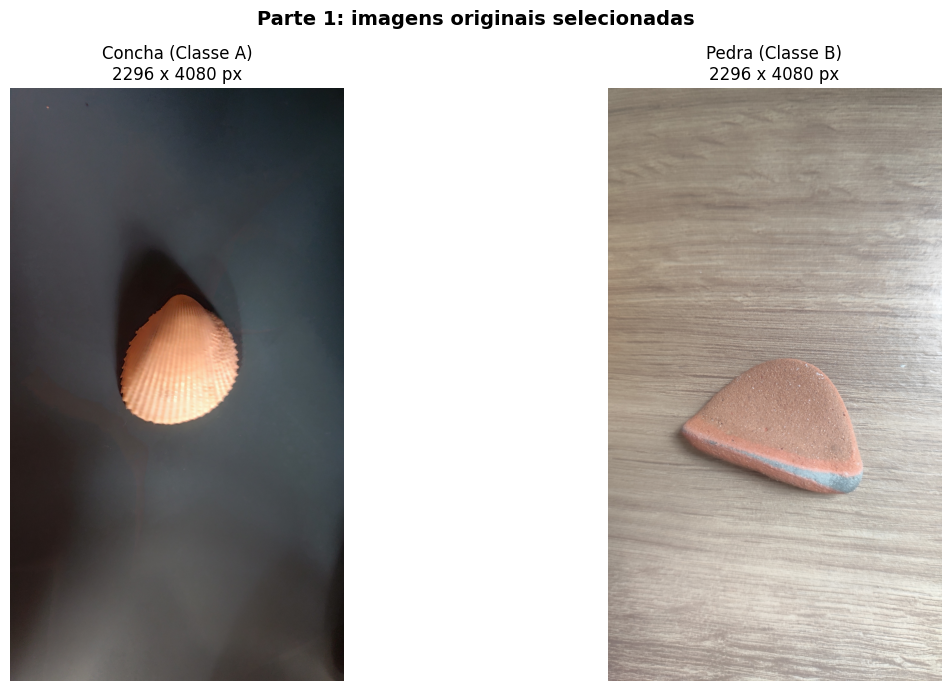

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
for ax, info in zip(axes, IMAGENS):
    arr = carregar_rgb(caminho(info))
    ax.imshow(arr)
    ax.set_title(f"{info['classe']}\n{arr.shape[1]} x {arr.shape[0]} px", fontsize=12)
    ax.axis('off')
plt.suptitle('Parte 1: imagens originais selecionadas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [4]:
# versões em tons de cinza (reduzidas) usadas em todo o pipeline de ruído e filtragem
BASE_GRAY = {info['cls']: redimensionar(carregar_gray(caminho(info))) for info in IMAGENS}
for cls, img in BASE_GRAY.items():
    print(f'{cls}: tons de cinza {img.shape[1]} x {img.shape[0]} px')


concha: tons de cinza 576 x 1024 px
pedra: tons de cinza 576 x 1024 px


### Parte 2: Inserção de ruído

Para cada imagem são geradas duas versões ruidosas, uma com ruído gaussiano e outra com ruído
sal e pimenta. O trabalho é feito em tons de cinza, pois isso deixa o efeito de cada ruído mais
evidente e simplifica a comparação com os filtros aplicados nas partes seguintes.


#### Ruído gaussiano

O ruído gaussiano soma a cada pixel um valor sorteado de uma distribuição normal de média 0 e
desvio padrão 25. A média 0 mantém o brilho geral da imagem e o desvio padrão controla a
intensidade da perturbação. O mapa de diferença à direita mostra onde o ruído atuou.


Parâmetros do ruído gaussiano: média = 0, desvio padrão = 25


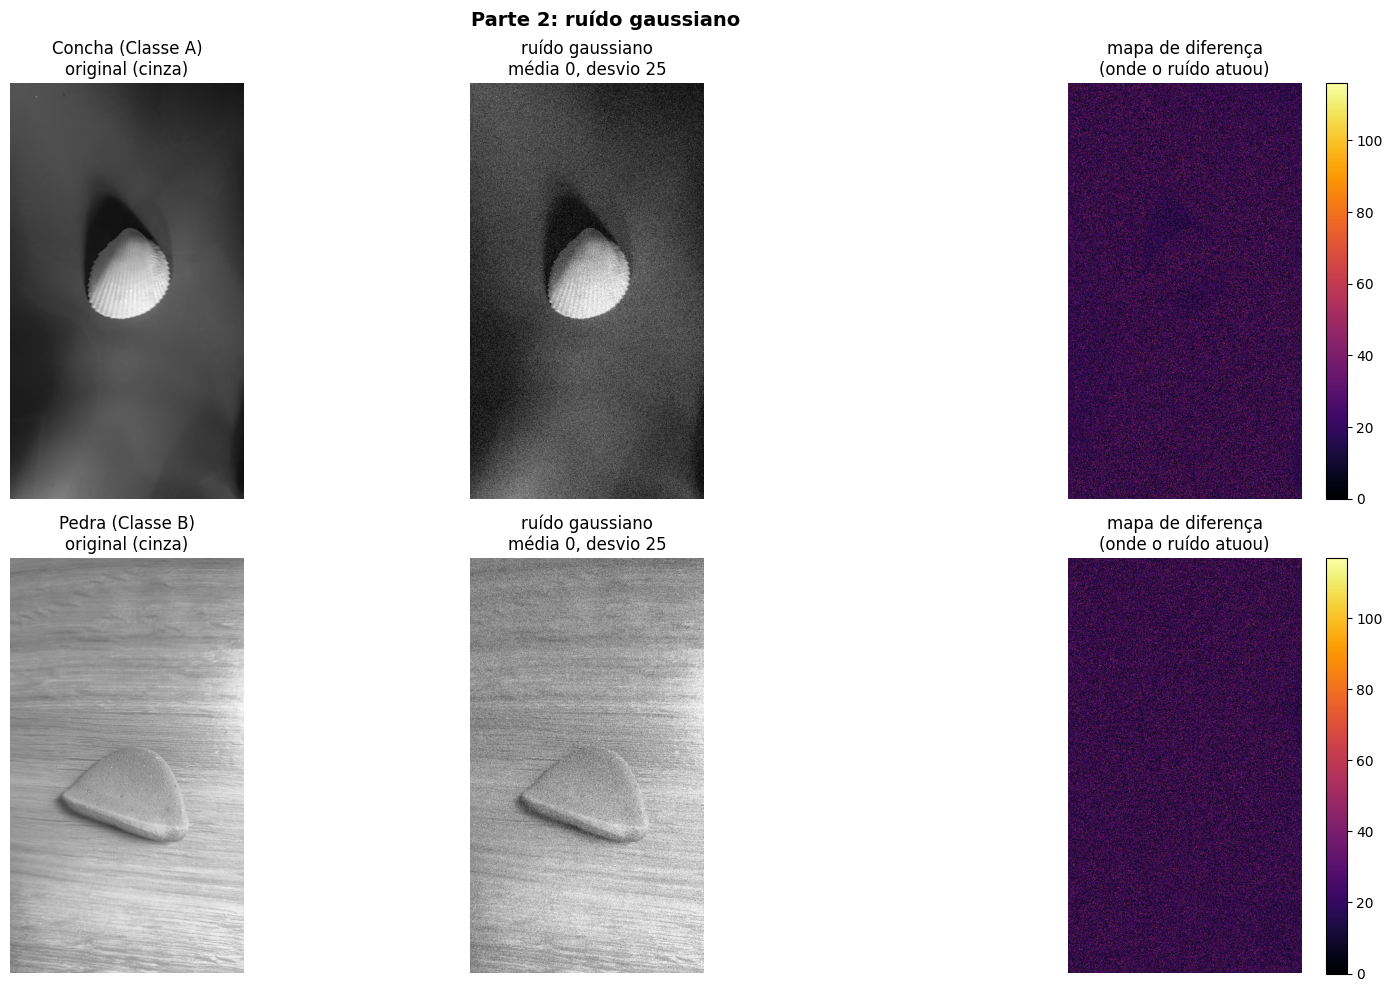

In [5]:
def ruido_gaussiano(img, media=0, desvio=25):
    ruido = np.random.normal(media, desvio, img.shape)
    return np.clip(img.astype(np.float64) + ruido, 0, 255).astype(np.uint8)


MEDIA_G, DESVIO_G = 0, 25
np.random.seed(42)
RUIDO_GAUSS = {cls: ruido_gaussiano(img, MEDIA_G, DESVIO_G) for cls, img in BASE_GRAY.items()}

print(f'Parâmetros do ruído gaussiano: média = {MEDIA_G}, desvio padrão = {DESVIO_G}')

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for linha, info in enumerate(IMAGENS):
    cls = info['cls']
    base = BASE_GRAY[cls]
    ruidosa = RUIDO_GAUSS[cls]
    dif = cv2.absdiff(ruidosa, base)

    axes[linha, 0].imshow(base, vmin=0, vmax=255)
    axes[linha, 0].set_title(f'{info["classe"]}\noriginal (cinza)')
    axes[linha, 1].imshow(ruidosa, vmin=0, vmax=255)
    axes[linha, 1].set_title(f'ruído gaussiano\nmédia {MEDIA_G}, desvio {DESVIO_G}')
    im = axes[linha, 2].imshow(dif, cmap='inferno')
    axes[linha, 2].set_title('mapa de diferença\n(onde o ruído atuou)')
    for j in range(3):
        axes[linha, j].axis('off')
    fig.colorbar(im, ax=axes[linha, 2], fraction=0.046, pad=0.04)

plt.suptitle('Parte 2: ruído gaussiano', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


**Impacto visual observado.** A imagem ganha uma granulação fina e homogênea por toda a
área. As regiões lisas, como o fundo, deixam de ser uniformes e passam a tremer; bordas e
texturas continuam visíveis, mas com menos nitidez.

**O ruído está distribuído uniformemente na imagem?** Sim, no sentido espacial. Como cada pixel
recebe um valor independente sorteado da mesma distribuição normal, a probabilidade de o ruído
atingir um pixel é a mesma em qualquer posição. O mapa de diferença confirma isso: a perturbação
aparece espalhada por todo o quadro, em áreas lisas e em bordas, sem concentração em regiões
específicas. O que varia não é a localização e sim a magnitude por pixel, que segue a curva em
sino (a maioria das alterações é pequena e poucas são grandes).

**Que problemas esse ruído pode causar para algoritmos de visão computacional?** Ele reduz a
relação sinal ruído e introduz pequenos gradientes falsos em toda a imagem. Isso atrapalha
detectores de borda e de cantos, que passam a responder ao ruído, prejudica a extração de
descritores (SIFT, ORB), degrada segmentações baseadas em limiar e diminui a acurácia de
classificadores. Como o erro se propaga, um pré-processamento mal feito compromete todas as
etapas seguintes do pipeline.


#### Ruído sal e pimenta

O ruído sal e pimenta troca uma fração dos pixels pelos valores extremos: metade vira branco
(sal, valor 255) e metade vira preto (pimenta, valor 0). Aqui foi usada uma probabilidade de
5% dos pixels, divididos igualmente entre sal e pimenta.


Probabilidade configurada: 5.0% dos pixels
Concha (Classe A): pixels efetivamente alterados = 4.88%
Pedra (Classe B): pixels efetivamente alterados = 4.88%


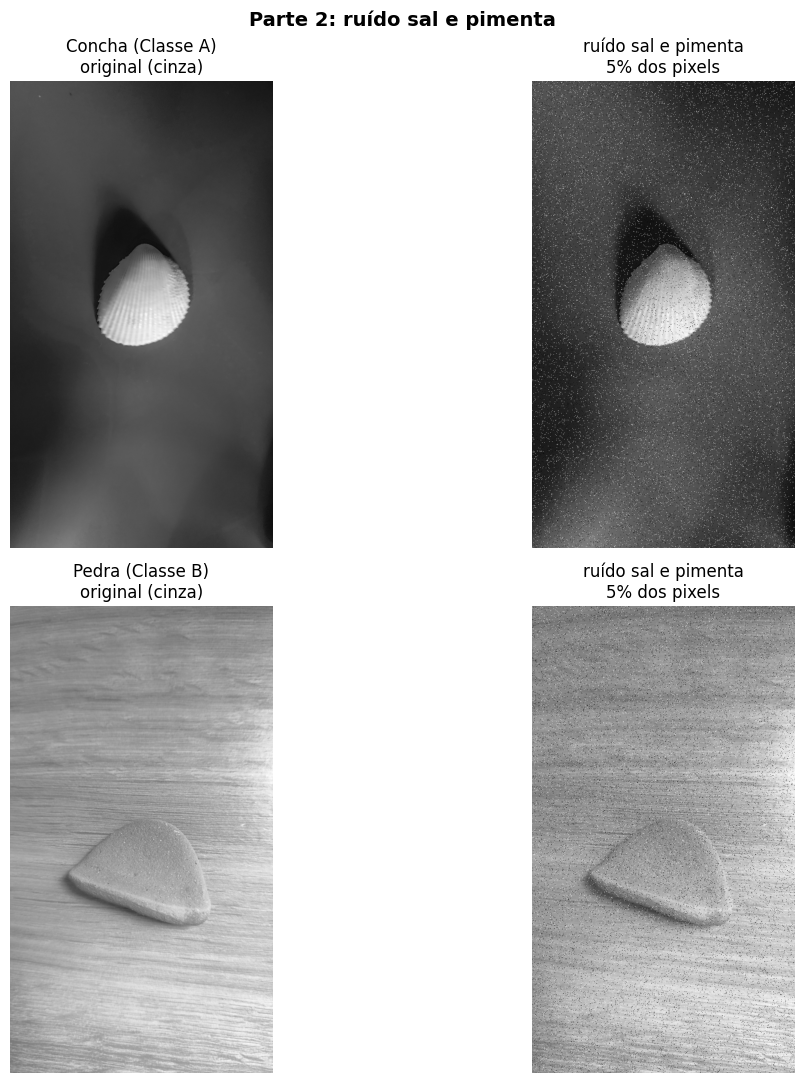

In [6]:
def ruido_sal_pimenta(img, prob=0.05):
    saida = img.copy()
    n = int(img.size * prob / 2)
    ys = np.random.randint(0, img.shape[0], n)
    xs = np.random.randint(0, img.shape[1], n)
    saida[ys, xs] = 255                      # sal
    ys = np.random.randint(0, img.shape[0], n)
    xs = np.random.randint(0, img.shape[1], n)
    saida[ys, xs] = 0                        # pimenta
    return saida


PROB_SP = 0.05
np.random.seed(7)
RUIDO_SP = {cls: ruido_sal_pimenta(img, PROB_SP) for cls, img in BASE_GRAY.items()}

print(f'Probabilidade configurada: {PROB_SP * 100:.1f}% dos pixels')
for info in IMAGENS:
    cls = info['cls']
    alterados = np.mean(RUIDO_SP[cls] != BASE_GRAY[cls]) * 100
    print(f'{info["classe"]}: pixels efetivamente alterados = {alterados:.2f}%')

fig, axes = plt.subplots(2, 2, figsize=(13, 11))
for linha, info in enumerate(IMAGENS):
    cls = info['cls']
    axes[linha, 0].imshow(BASE_GRAY[cls], vmin=0, vmax=255)
    axes[linha, 0].set_title(f'{info["classe"]}\noriginal (cinza)')
    axes[linha, 1].imshow(RUIDO_SP[cls], vmin=0, vmax=255)
    axes[linha, 1].set_title('ruído sal e pimenta\n5% dos pixels')
    for j in range(2):
        axes[linha, j].axis('off')
plt.suptitle('Parte 2: ruído sal e pimenta', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


**Porcentagem de pixels alterados.** A configuração usa 5% dos pixels (2,5% sal e 2,5%
pimenta). O valor medido fica um pouco abaixo de 5% porque os sorteios podem repetir a mesma
posição e porque um pixel já branco que recebe sal não muda de valor.

**Como esse ruído se diferencia visualmente do ruído gaussiano?** O gaussiano altera levemente
quase todos os pixels e produz uma granulação suave por toda a imagem. O sal e pimenta faz o
oposto: altera poucos pixels, mas de forma drástica, jogando cada um para preto ou branco puro.
O resultado são pontos isolados pretos e brancos sobre a imagem, em vez de uma textura contínua.

**Em quais situações esse ruído aparece em sistemas reais de captura?** Costuma vir de falhas
pontuais de hardware e transmissão: pixels defeituosos no sensor, erros de bit na conversão
analógico digital, células de memória com defeito, pacotes corrompidos durante a transmissão da
imagem e interferência eletromagnética. São causas que afetam pixels individuais, não a imagem
inteira.


### Parte 3: Filtro passa-baixo

A filtragem é feita no domínio da frequência. A imagem é levada ao espectro com a transformada
de Fourier (FFT), onde o centro concentra as baixas frequências (estrutura geral e áreas lisas)
e as extremidades concentram as altas frequências (detalhes finos e ruído). O filtro passa-baixo
multiplica o espectro por uma máscara que mantém o centro e atenua as bordas, deixando passar só
as baixas frequências. São testados dois níveis de corte: um corte largo (D0 = 120, suavização
leve) e um corte estreito (D0 = 30, suavização forte). Quanto menor o raio de corte, mais
frequências são removidas e mais forte é a suavização.


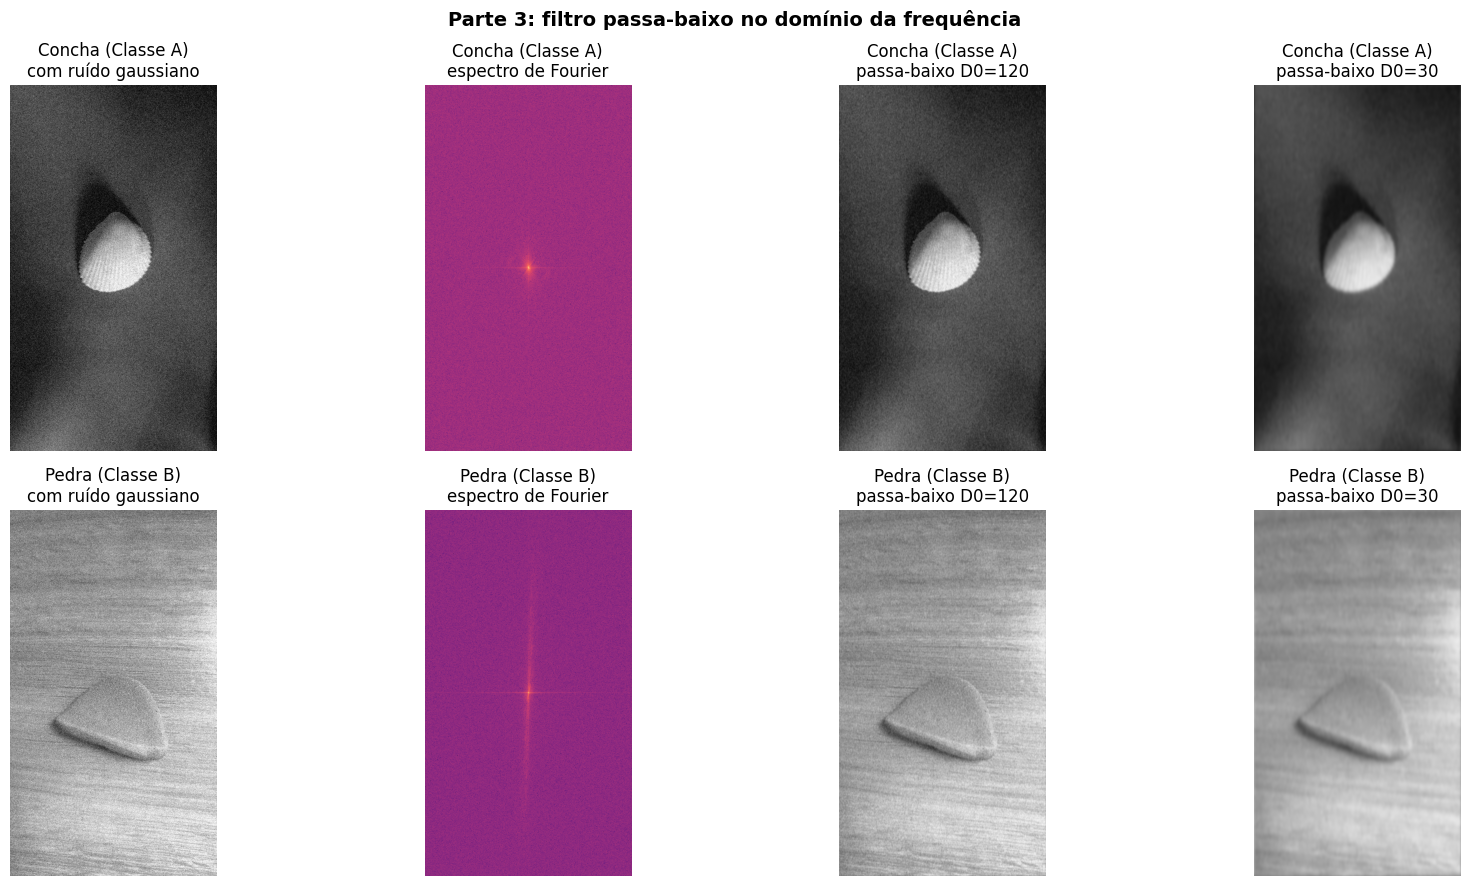

           imagem              etapa  sigma ruído  energia borda
Concha (Classe A)            ruidosa        24.77          107.2
Concha (Classe A) passa-baixo D0=120         0.59           35.3
Concha (Classe A)  passa-baixo D0=30         0.23            5.2
 Pedra (Classe B)            ruidosa        25.06          115.8
 Pedra (Classe B) passa-baixo D0=120         0.60           40.4
 Pedra (Classe B)  passa-baixo D0=30         0.26            6.9


In [7]:
linhas = []
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
for i, info in enumerate(IMAGENS):
    cls = info['cls']
    ruidosa = RUIDO_GAUSS[cls]
    pb_largo = np.clip(filtro_freq(ruidosa, 120, 'baixo'), 0, 255).astype(np.uint8)
    pb_estreito = np.clip(filtro_freq(ruidosa, 30, 'baixo'), 0, 255).astype(np.uint8)

    for nome, img in [('ruidosa', ruidosa),
                      ('passa-baixo D0=120', pb_largo),
                      ('passa-baixo D0=30', pb_estreito)]:
        linhas.append({
            'imagem': info['classe'],
            'etapa': nome,
            'sigma ruído': round(estimar_ruido(img), 2),
            'energia borda': round(energia_borda(img), 1),
        })

    painel = [('com ruído gaussiano', ruidosa),
              ('espectro de Fourier', espectro(ruidosa)),
              ('passa-baixo D0=120', pb_largo),
              ('passa-baixo D0=30', pb_estreito)]
    for j, (titulo, img) in enumerate(painel):
        if 'espectro' in titulo:
            axes[i, j].imshow(img, cmap='magma')
        else:
            axes[i, j].imshow(img, cmap='gray', vmin=0, vmax=255)
        axes[i, j].set_title(f'{info["classe"]}\n{titulo}')
        axes[i, j].axis('off')

plt.suptitle('Parte 3: filtro passa-baixo no domínio da frequência',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

df_passabaixo = pd.DataFrame(linhas)
print(df_passabaixo.to_string(index=False))


**O filtro conseguiu reduzir o ruído?** Sim. O espectro mostra que o ruído gaussiano espalha
energia para as altas frequências (as regiões externas do espectro). Como o passa-baixo atenua
justamente essas extremidades, o sigma estimado cai bastante, e a queda é maior com o corte
estreito (D0 = 30) do que com o corte largo (D0 = 120).

**Que detalhes da imagem foram perdidos?** As bordas e as texturas finas também são altas
frequências, então parte delas é removida junto com o ruído. Com o corte estreito isso fica
nítido: os contornos do objeto ficam mais borrados e a energia de borda cai mais. O corte largo
perde menos detalhe.

**Qual corte apresentou melhor equilíbrio?** O corte largo (D0 = 120) preserva mais detalhe e já
remove boa parte do ruído, sendo o melhor equilíbrio quando o objetivo é manter a silhueta do
objeto. O corte estreito limpa mais, mas ao custo de borrar o objeto. Vale notar que o passa-baixo
não é a melhor escolha para o ruído sal e pimenta, cujos picos isolados têm energia espalhada por
toda a faixa de frequências, e nesse caso o filtro de mediana é mais adequado.


### Parte 4: Filtro passa-alto

O filtro passa-alto é o complemento do passa-baixo no domínio da frequência: a máscara mantém as
altas frequências (as extremidades do espectro, onde estão as bordas e os detalhes finos) e
atenua as baixas (o centro). Foi aplicado sobre as imagens com ruído gaussiano, com raio de corte
D0 = 20, mantendo a original como referência.


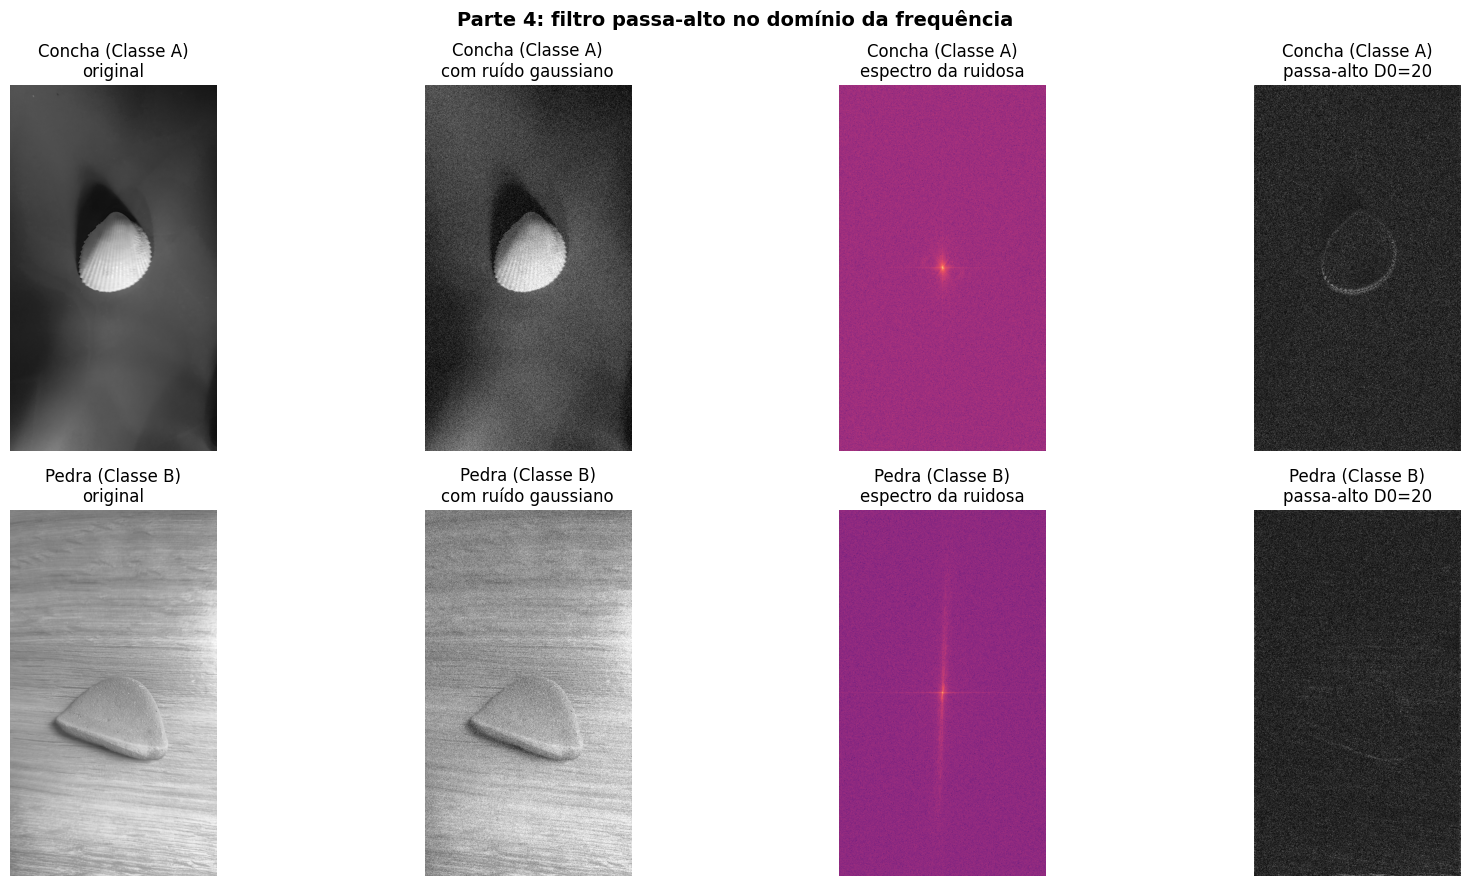

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
for i, info in enumerate(IMAGENS):
    cls = info['cls']
    base = BASE_GRAY[cls]
    ruidosa = RUIDO_GAUSS[cls]
    passa_alto = normalizar(filtro_freq(ruidosa, 20, 'alto'))

    painel = [('original', base),
              ('com ruído gaussiano', ruidosa),
              ('espectro da ruidosa', espectro(ruidosa)),
              ('passa-alto D0=20', passa_alto)]
    for j, (titulo, img) in enumerate(painel):
        if 'espectro' in titulo:
            axes[i, j].imshow(img, cmap='magma')
        else:
            axes[i, j].imshow(img, cmap='gray', vmin=0, vmax=255)
        axes[i, j].set_title(f'{info["classe"]}\n{titulo}')
        axes[i, j].axis('off')

plt.suptitle('Parte 4: filtro passa-alto no domínio da frequência',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


**Que estruturas da imagem foram destacadas?** As bordas e os contornos do objeto, além das
transições bruscas de intensidade e da textura. As regiões lisas viram preto, porque ali não há
alta frequência para realçar.

**As bordas ficaram mais visíveis?** Sim, o contorno do objeto fica evidente, mas o ruído também
foi realçado junto. Como o passa-alto amplifica as altas frequências e o ruído gaussiano é
justamente alta frequência, a imagem fica granulada e cheia de bordas falsas. É por isso que, na
prática, costuma-se aplicar um passa-baixo antes do passa-alto.

**Esse tipo de filtro ajudaria em quais tarefas de visão computacional?** Em tarefas que dependem
de contornos e detalhes: detecção de bordas e de objetos, realce e nitidez, extração de
características, OCR, inspeção industrial e segmentação por contorno. O resultado aqui reforça que
o passa-alto só é útil depois de reduzir o ruído.


### Parte 5: Comparação final

A figura abaixo reúne, para uma mesma imagem, todas as etapas do experimento lado a lado. Em
seguida, uma tabela quantitativa registra o sigma de ruído, a variância e a energia de borda de
cada etapa, servindo de base objetiva para a comparação.


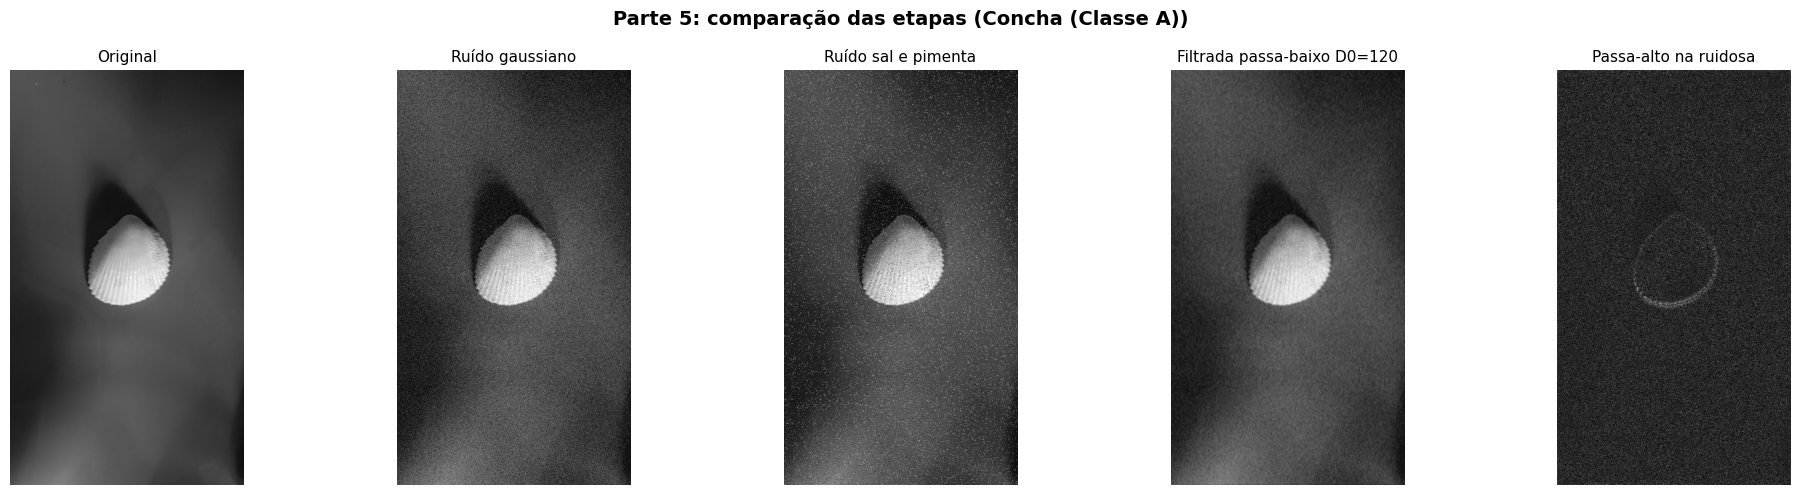

                      etapa  sigma ruído  variância  energia borda
                   Original         1.04     1111.0            7.3
            Ruído gaussiano        24.77     1686.0          107.2
        Ruído sal e pimenta        19.31     1991.0           81.5
Filtrada passa-baixo D0=120         0.59     1123.0           35.3
      Passa-alto na ruidosa        29.93      915.0          129.4


In [9]:
ALVO = IMAGENS[0]          # concha (Classe A)
cls = ALVO['cls']
base = BASE_GRAY[cls]
g_noisy = RUIDO_GAUSS[cls]
sp_noisy = RUIDO_SP[cls]
filtrada = np.clip(filtro_freq(g_noisy, 120, 'baixo'), 0, 255).astype(np.uint8)
passa_alta = normalizar(filtro_freq(g_noisy, 20, 'alto'))

estagios = [
    ('Original', base),
    ('Ruído gaussiano', g_noisy),
    ('Ruído sal e pimenta', sp_noisy),
    ('Filtrada passa-baixo D0=120', filtrada),
    ('Passa-alto na ruidosa', passa_alta),
]

fig, axes = plt.subplots(1, 5, figsize=(20, 5))
for ax, (titulo, img) in zip(axes, estagios):
    ax.imshow(img, vmin=0, vmax=255)
    ax.set_title(titulo, fontsize=11)
    ax.axis('off')
plt.suptitle(f'Parte 5: comparação das etapas ({ALVO["classe"]})',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

resumo = [{
    'etapa': titulo,
    'sigma ruído': round(estimar_ruido(img), 2),
    'variância': round(float(img.var()), 0),
    'energia borda': round(energia_borda(img), 1),
} for titulo, img in estagios]

df_final = pd.DataFrame(resumo)
print(df_final.to_string(index=False))


#### Tabela de comparação

| Etapa | Resultado observado |
| --- | --- |
| Imagem original | Referência limpa, baixo sigma de ruído, bordas e textura bem definidas. |
| Imagem com ruído gaussiano | Granulação fina e homogênea em toda a área. O sigma do ruído sobe de cerca de 1 para cerca de 25 e a energia de borda dispara, refletindo perturbação em todos os pixels. |
| Imagem com ruído sal e pimenta | Pontos pretos e brancos isolados. Afeta poucos pixels (cerca de 5%), mas com valores extremos, o que eleva a variância acima da do gaussiano. O sigma estimado também sobe bastante, porém menos que no gaussiano. |
| Imagem filtrada com passa-baixo | Altas frequências atenuadas no espectro, ruído gaussiano bastante reduzido e sigma cai, em troca as bordas e a textura ficam mais suaves. |
| Imagem com filtro passa-alto | Aplicado sobre a imagem com ruído, realça bordas e contornos, mas amplifica junto o ruído (alta frequência), o que reforça a necessidade de suavizar antes. |

**Qual ruído degradou mais a imagem?** Depende do critério, e os números da tabela ajudam a
separar os efeitos. Pelo sigma estimado e pela energia de borda, o ruído gaussiano degradou mais
(sigma em torno de 25 contra 19 do sal e pimenta, e energia de borda bem maior), porque perturba
todos os pixels ao mesmo tempo e derruba a relação sinal ruído na imagem inteira. Já o sal e
pimenta eleva mais a variância, por causa dos valores extremos 0 e 255, e é o mais agressivo em
cada pixel atingido, mas alcança apenas cerca de 5% deles. Em resumo, o gaussiano degrada de
forma global e mensurável, enquanto o sal e pimenta é local e extremo, chamando mais atenção
visual em pontos isolados. Para detecção de bordas, o gaussiano espalha gradientes falsos por
todo o quadro e o sal e pimenta cria bordas falsas pontuais.

**O filtro passa-baixo conseguiu recuperar a qualidade visual?** Para o ruído gaussiano, sim, com
boa recuperação, já que é o caso ideal de um passa-baixo. Para o ruído sal e pimenta, não: por
ser um filtro linear, ele espalha os pixels extremos em manchas cinzas em vez de removê-los; ali
o filtro de mediana seria a escolha correta. A recuperação, portanto, depende da combinação certa
entre o tipo de ruído e o tipo de filtro.

**Em quais aplicações de visão computacional seria importante aplicar filtros antes do
processamento?** Sempre que a etapa seguinte for sensível a ruído: detecção de bordas e cantos,
segmentação, OCR, reconhecimento e classificação de objetos, inspeção industrial, imagens médicas
e visão embarcada com sensores baratos ou capturas em pouca luz e ISO alto. Nesses casos, filtrar
antes melhora a qualidade dos dados e o desempenho de todo o pipeline.


## Conclusão

Cada ruído pede uma resposta diferente: o passa-baixo recupera bem o ruído gaussiano,
mas borra detalhes com kernels maiores e falha contra o sal e pimenta (onde a mediana seria
melhor), enquanto o passa-alto segue o caminho oposto e realça as bordas. Não existe filtro
universal: a escolha depende do tipo de degradação e do objetivo do pipeline. Para classificar
concha e pedra pela silhueta, preservar bordas pesa mais do que eliminar todo o ruído, o que
favorece kernels menores.
